### CONEXION DDBB OLIST

In [21]:
# ===========================================
# DEPENDENCIAS Y CONEXIÓN A LA BASE DE DATOS
# ===========================================

from sqlalchemy import create_engine, text
import ssl
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import numpy as np


DB_USER = "nuclio"
DB_PASS = "nuclioTFM6"
DB_HOST = "nuclio.mysql.database.azure.com"
DB_NAME = "olist"

# Crear conexión (engine)
engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:3306/{DB_NAME}?charset=utf8mb4",
    pool_pre_ping=True,
    connect_args={"ssl": {"cert_reqs": ssl.CERT_NONE, "check_hostname": False}} 
)

# --------------------------------------
#  Mostrar las tablas disponibles
# --------------------------------------

with engine.connect() as conn:
    tables = conn.execute(text("SHOW TABLES")).fetchall()
    tables = [row[0] for row in tables]

print("📦 Tablas en la base 'olist':")
for t in tables:
    print("-", t)




📦 Tablas en la base 'olist':
- dash_olist_categorias_resumen
- dash_olist_demorados
- dash_olist_sellers
- dash_olist_states
- dash_olist_ventas_meses
- dash_sentiment_analysis
- distribucion_pedidos
- olist_customers_dataset
- olist_geolocation_dataset
- olist_order_items_dataset
- olist_order_payments_dataset
- olist_order_reviews_dataset
- olist_orders_dataset
- olist_products_dataset
- olist_sellers_dataset
- pedidos_por_tiempo
- product_category_name_translation


### 1. TABLA: Volumen y peso promedio de todos los productos

#### Tabla: `olist_products_dataset` — Productos

,id,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,2,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,3,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,4,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,5,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Peso promedio: 2276.47 g
Longitud promedio: 30.82 cm


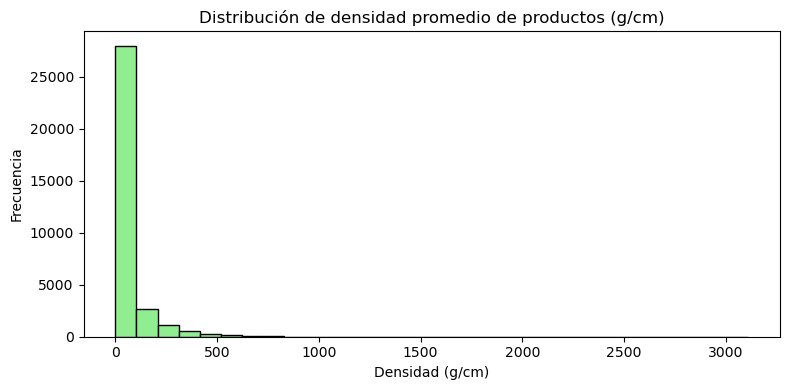

Densidad promedio aproximada: 61.70 g/cm


In [27]:
# --------------------------------------
#  Cargar tabla de productos
# --------------------------------------

table = "olist_products_dataset"

if table in tables:
    df_products = pd.read_sql_query(f"SELECT * FROM `{table}`", con=engine)

    display(Markdown(f"#### Tabla: `{table}` — Productos"))
    display(df_products.head())

    # Calcular promedio de peso (no hay volumen completo)
    avg_weight = df_products["product_weight_g"].mean()
    avg_length = df_products["product_length_cm"].mean()

    print(f"Peso promedio: {avg_weight:.2f} g")
    print(f"Longitud promedio: {avg_length:.2f} cm")


    # ======================================================
    #  Gráfica: Densidad promedio de productos
    # ======================================================

    # Calculamos densidad aproximada: peso / longitud (g/cm)
    df_products["density_g_per_cm"] = df_products["product_weight_g"] / df_products["product_length_cm"]

    # Eliminamos valores no válidos
    df_products = df_products.replace([np.inf, -np.inf], np.nan).dropna(subset=["density_g_per_cm"])

    # Gráfica de densidad (histograma)
    plt.figure(figsize=(8,4))
    plt.hist(df_products["density_g_per_cm"], bins=30, color="lightgreen", edgecolor="black")
    plt.title("Distribución de densidad promedio de productos (g/cm)")
    plt.xlabel("Densidad (g/cm)")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

    # Imprimir densidad media general
    avg_density = df_products["density_g_per_cm"].mean()
    print(f"Densidad promedio aproximada: {avg_density:.2f} g/cm")

else:
    print(f" La tabla '{table}' no existe en la base de datos.")

### 2. TABLA: Volumen y peso promedio de los pedidos

#### Tabla: Promedios de peso y longitud por pedido

,order_id,product_weight_g,product_length_cm
0,00010242fe8c5a6d1ba2dd792cb16214,650.0,28.0
1,00018f77f2f0320c557190d7a144bdd3,30000.0,50.0
2,000229ec398224ef6ca0657da4fc703e,3050.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,200.0,16.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,3750.0,35.0


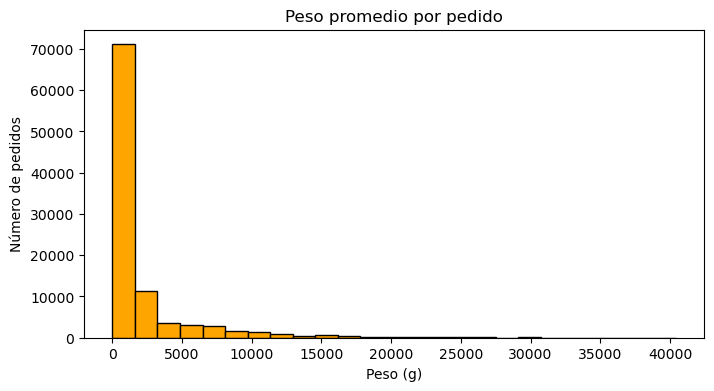

In [23]:
# --------------------------------------
# 4️⃣ Tabla 2: Promedio por pedido
# --------------------------------------

query = """
SELECT 
    oi.order_id,
    p.product_id,
    p.product_weight_g,
    p.product_length_cm
FROM olist_order_items_dataset AS oi
JOIN olist_products_dataset AS p ON p.product_id = oi.product_id
"""
df_joined = pd.read_sql_query(query, con=engine)

# Calcular promedio de peso y largo por pedido
df_order_avg = (
    df_joined.groupby("order_id")[["product_weight_g", "product_length_cm"]]
    .mean()
    .reset_index()
)

display(Markdown("#### Tabla: Promedios de peso y longitud por pedido"))
display(df_order_avg.head())

# 📊 Gráfica simple: peso promedio por pedido
plt.figure(figsize=(8,4))
plt.hist(df_order_avg["product_weight_g"].dropna(), bins=25, color="orange", edgecolor="black")
plt.title("Peso promedio por pedido")
plt.xlabel("Peso (g)")
plt.ylabel("Número de pedidos")
plt.show()




### 3. TABLA: Eficiencia logística

#### Tabla: Eficiencia logística por pedido

,order_id,distance_km,weight_kg,freight_value,km_per_kg
0,00010242fe8c5a6d1ba2dd792cb16214,301.504681,0.65,13.29,463.853355
1,00018f77f2f0320c557190d7a144bdd3,585.563937,30.00,19.93,19.518798
2,000229ec398224ef6ca0657da4fc703e,312.343511,3.05,17.87,102.407709
3,00024acbcdf0a6daa1e931b038114c75,293.168420,0.20,12.79,1465.842099
4,00042b26cf59d7ce69dfabb4e55b4fd9,646.163463,3.75,18.14,172.310257


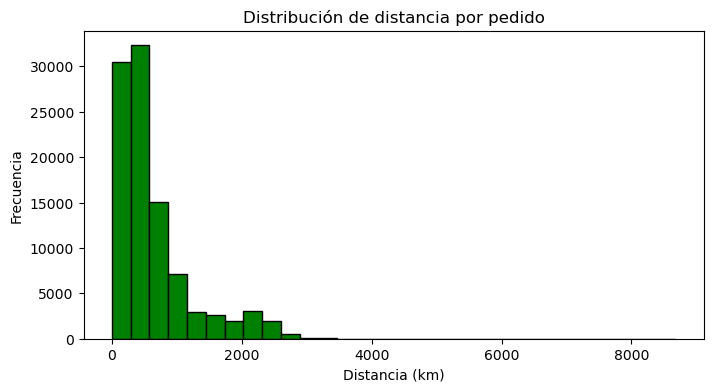

In [24]:
# --------------------------------------
# 5️⃣ Tabla 3: Eficiencia logística
# --------------------------------------

from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    """Calcula distancia (km) entre 2 puntos por lat/lon."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

# Cargar datasets
customers = pd.read_sql("SELECT customer_id, customer_zip_code_prefix FROM olist_customers_dataset", con=engine)
sellers = pd.read_sql("SELECT seller_id, seller_zip_code_prefix FROM olist_sellers_dataset", con=engine)
geos = pd.read_sql("""
    SELECT geolocation_zip_code_prefix,
           AVG(geolocation_lat) AS lat,
           AVG(geolocation_lng) AS lng
    FROM olist_geolocation_dataset
    GROUP BY geolocation_zip_code_prefix
""", con=engine)
order_items = pd.read_sql("SELECT order_id, product_id, seller_id, price, freight_value FROM olist_order_items_dataset", con=engine)
products = pd.read_sql("SELECT product_id, product_weight_g, product_length_cm FROM olist_products_dataset", con=engine)
orders = pd.read_sql("SELECT order_id, customer_id FROM olist_orders_dataset", con=engine)

# Combinar
df = (order_items
      .merge(products, on="product_id", how="left")
      .merge(orders, on="order_id", how="left")
      .merge(customers, on="customer_id", how="left")
      .merge(sellers, on="seller_id", how="left", suffixes=("_cust", "_sell"))
)

# Añadir coordenadas promedio
df = (df
      .merge(geos, left_on="customer_zip_code_prefix", right_on="geolocation_zip_code_prefix", how="left")
      .rename(columns={"lat": "lat_cust", "lng": "lng_cust"})
      .merge(geos, left_on="seller_zip_code_prefix", right_on="geolocation_zip_code_prefix", how="left")
      .rename(columns={"lat": "lat_sell", "lng": "lng_sell"})
)

# Calcular distancia
df["distance_km"] = df.apply(
    lambda x: haversine(x.lat_cust, x.lng_cust, x.lat_sell, x.lng_sell)
    if pd.notnull(x.lat_cust) and pd.notnull(x.lat_sell) else None,
    axis=1
)

df["weight_kg"] = df["product_weight_g"] / 1000

order_efficiency = df.groupby("order_id").agg({
    "distance_km": "mean",
    "weight_kg": "sum",
    "freight_value": "sum"
}).reset_index()

order_efficiency["km_per_kg"] = order_efficiency["distance_km"] / order_efficiency["weight_kg"]

display(Markdown("#### Tabla: Eficiencia logística por pedido"))
display(order_efficiency.head())

# 📊 Gráfica simple: distancia promedio
plt.figure(figsize=(8,4))
plt.hist(order_efficiency["distance_km"].dropna(), bins=30, color="green", edgecolor="black")
plt.title("Distribución de distancia por pedido")
plt.xlabel("Distancia (km)")
plt.ylabel("Frecuencia")
plt.show()

#### Tabla: Promedios de peso y longitud por pedido

,order_id,product_weight_g,product_length_cm
0,00010242fe8c5a6d1ba2dd792cb16214,650.0,28.0
1,00018f77f2f0320c557190d7a144bdd3,30000.0,50.0
2,000229ec398224ef6ca0657da4fc703e,3050.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,200.0,16.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,3750.0,35.0


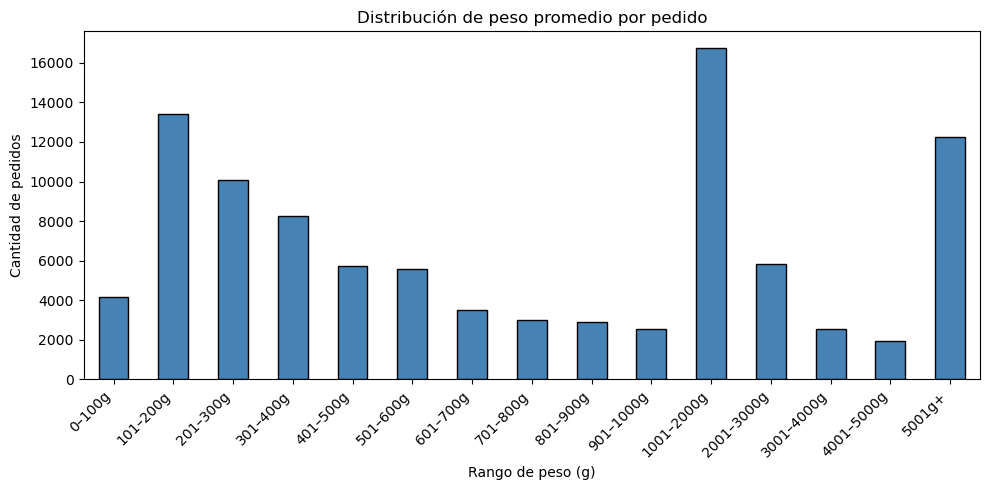

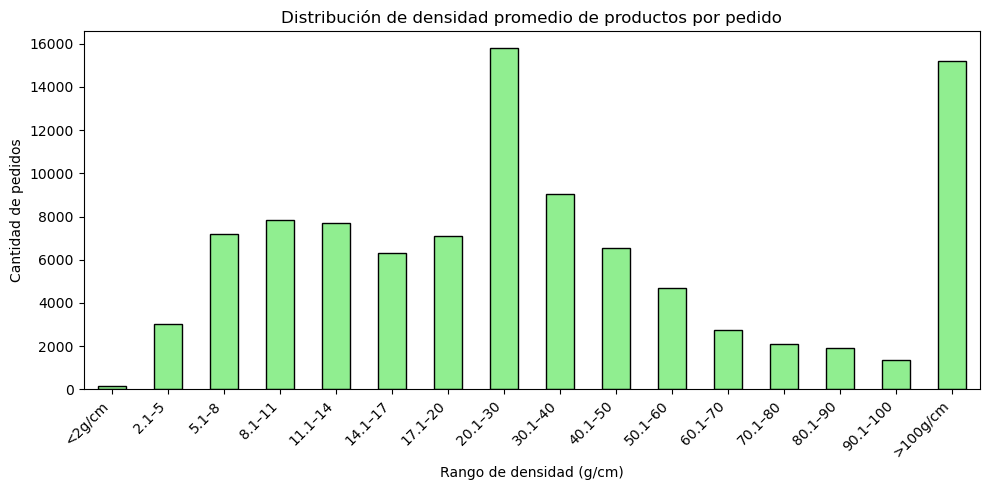

Densidad promedio general: 60.17 g/cm


In [ ]:
# ======================================================
# Cargar y preparar los datos combinados
# ======================================================

query = """
SELECT 
    oi.order_id,
    p.product_id,
    p.product_weight_g,
    p.product_length_cm
FROM olist_order_items_dataset AS oi
JOIN olist_products_dataset AS p ON p.product_id = oi.product_id
"""
df_joined = pd.read_sql_query(query, con=engine)

# Calcular promedio de peso y largo por pedido
df_order_avg = (
    df_joined.groupby("order_id")[["product_weight_g", "product_length_cm"]]
    .mean()
    .reset_index()
)

display(Markdown("#### Tabla: Promedios de peso y longitud por pedido"))
display(df_order_avg.head())

# ======================================================
# Gráfica de distribución del peso (por intervalos definidos)
# ======================================================

# Definir bins de peso (g)
bins_weight = [0,100,200,300,400,500,600,700,800,900,1000,
               2000,3000,4000,5000,999999]
labels_weight = [
    "0–100g","101–200g","201–300g","301–400g","401–500g",
    "501–600g","601–700g","701–800g","801–900g","901–1000g",
    "1001–2000g","2001–3000g","3001–4000g","4001–5000g","5001g+"
]

# Clasificar por rango de peso
df_order_avg["weight_range"] = pd.cut(df_order_avg["product_weight_g"],
                                      bins=bins_weight, labels=labels_weight, right=True)

# Contar productos por rango
weight_dist = df_order_avg["weight_range"].value_counts().sort_index()

# Graficar
plt.figure(figsize=(10,5))
weight_dist.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Distribución de peso promedio por pedido")
plt.xlabel("Rango de peso (g)")
plt.ylabel("Cantidad de pedidos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ======================================================
# Gráfica de densidad promedio (peso / longitud)
# ======================================================

# Calcular densidad g/cm
df_order_avg["density_g_per_cm"] = df_order_avg["product_weight_g"] / df_order_avg["product_length_cm"]

# Limpiar valores inválidos
df_order_avg = df_order_avg.replace([np.inf, -np.inf], np.nan).dropna(subset=["density_g_per_cm"])

# Definir bins de densidad
bins_density = [0,2,5,8,11,14,17,20,30,40,50,60,70,80,90,100,999999]
labels_density = [
    "<2g/cm", "2.1–5", "5.1–8", "8.1–11", "11.1–14",
    "14.1–17", "17.1–20", "20.1–30", "30.1–40", "40.1–50",
    "50.1–60", "60.1–70", "70.1–80", "80.1–90", "90.1–100", ">100g/cm"
]

# Clasificar por rango de densidad
df_order_avg["density_range"] = pd.cut(df_order_avg["density_g_per_cm"],
                                       bins=bins_density, labels=labels_density, right=True)

# Contar densidades por rango
density_dist = df_order_avg["density_range"].value_counts().sort_index()

# Graficar densidad
plt.figure(figsize=(10,5))
density_dist.plot(kind="bar", color="lightgreen", edgecolor="black")
plt.title("Distribución de densidad promedio de productos por pedido")
plt.xlabel("Rango de densidad (g/cm)")
plt.ylabel("Cantidad de pedidos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Mostrar densidad media
avg_density = df_order_avg["density_g_per_cm"].mean()
print(f"Densidad promedio general: {avg_density:.2f} g/cm")